In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
# this was running on 4 utah m400 machines (8 cores each, 32 cores total, no smt)

In [4]:
df = pd.read_csv("distributed_log.csv").set_index(["test_type", "n", "num_cpus"])
df["admm_time"] = df["solve"] - df["_get_grouped_objectives"] - df["get_subproblems"] - df["populate_vars_with_solution"]
df["admm_time_per_iter"] = df["admm_time"] / df["num_iterations"]
df["group_time"] = df["_get_grouped_objectives"]
df["misc_time"] = df["__init__"] + df["get_subproblems"] + df["populate_vars_with_solution"]
df = df.rename({"solve": "total_time"}, axis=1)
df

,,,num_iterations,__init__,_get_grouped_objectives,get_subproblems,populate_vars_with_solution,total_time,result,admm_time,admm_time_per_iter,group_time,misc_time
test_type,n,num_cpus,,,,,,,,,,,
sum,80,1,4,0.2792,5.2719,0.4231,0.4464,16.2071,3158.959731,10.0657,2.516425,5.2719,1.1487
weighted,30,1,24,0.0743,5.6355,0.1077,0.0822,17.4628,228.168234,11.6374,0.484892,5.6355,0.2642
log,10,1,7,0.0281,4.4129,0.0498,0.0189,7.5810,131.748929,3.0994,0.442771,4.4129,0.0968
sum,80,2,4,0.3203,4.7622,0.5045,0.3403,12.9455,3158.959731,7.3385,1.834625,4.7622,1.1651
weighted,30,2,37,0.0691,5.4426,0.1308,0.0701,15.0391,276.386649,9.3956,0.253935,5.4426,0.2700
...,...,...,...,...,...,...,...,...,...,...,...,...,...
log,300,16,2,2.8577,288.8638,9.7523,3.8717,473.2171,NaN,170.7293,85.364650,288.8638,16.4817
weighted,900,32,4,25.7845,78.3166,51.6614,25.2268,235.8756,5335.611597,80.6708,20.167700,78.3166,102.6727
log,300,32,2,2.9771,288.1290,11.2329,2.6316,410.8697,NaN,108.8762,54.438100,288.1290,16.8416


In [5]:
TEST_TYPES = ["sum", "weighted", "log"]
SHAREY = False  # set True to synchronize y-axes across subplots

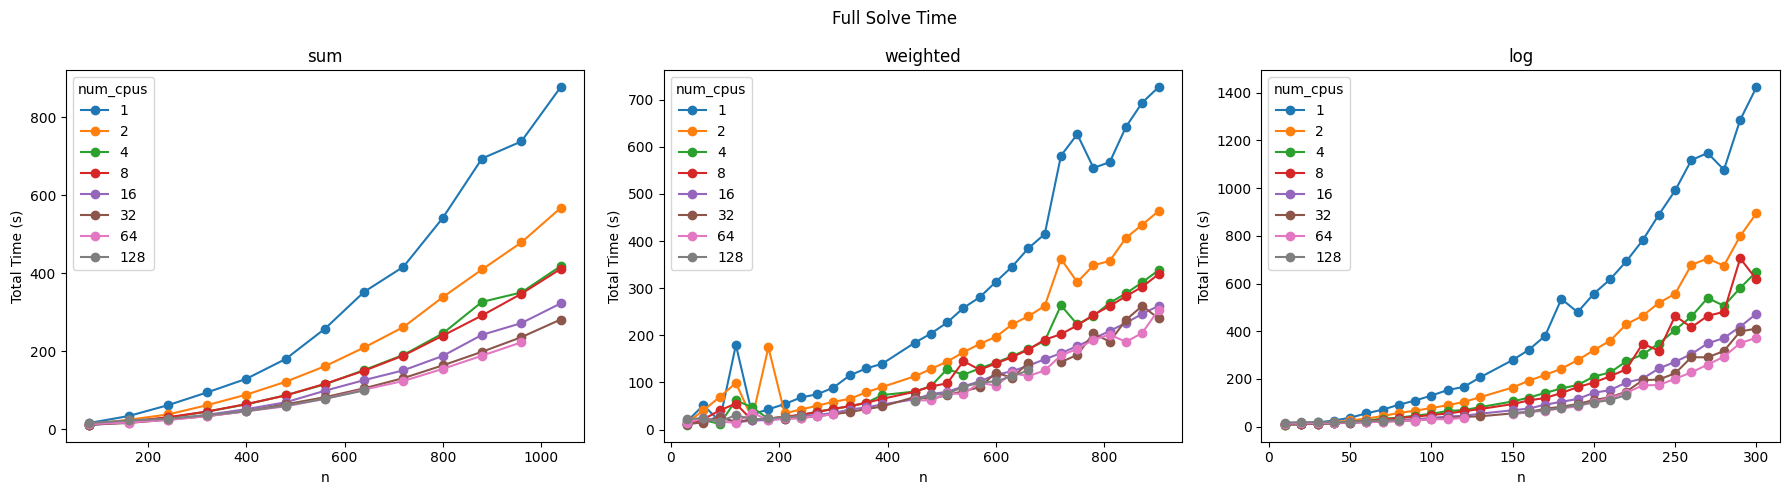

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["total_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["total_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Total Time (s)")
    ax.set_title(test_type)
fig.suptitle("Full Solve Time")
fig.tight_layout()
plt.show()

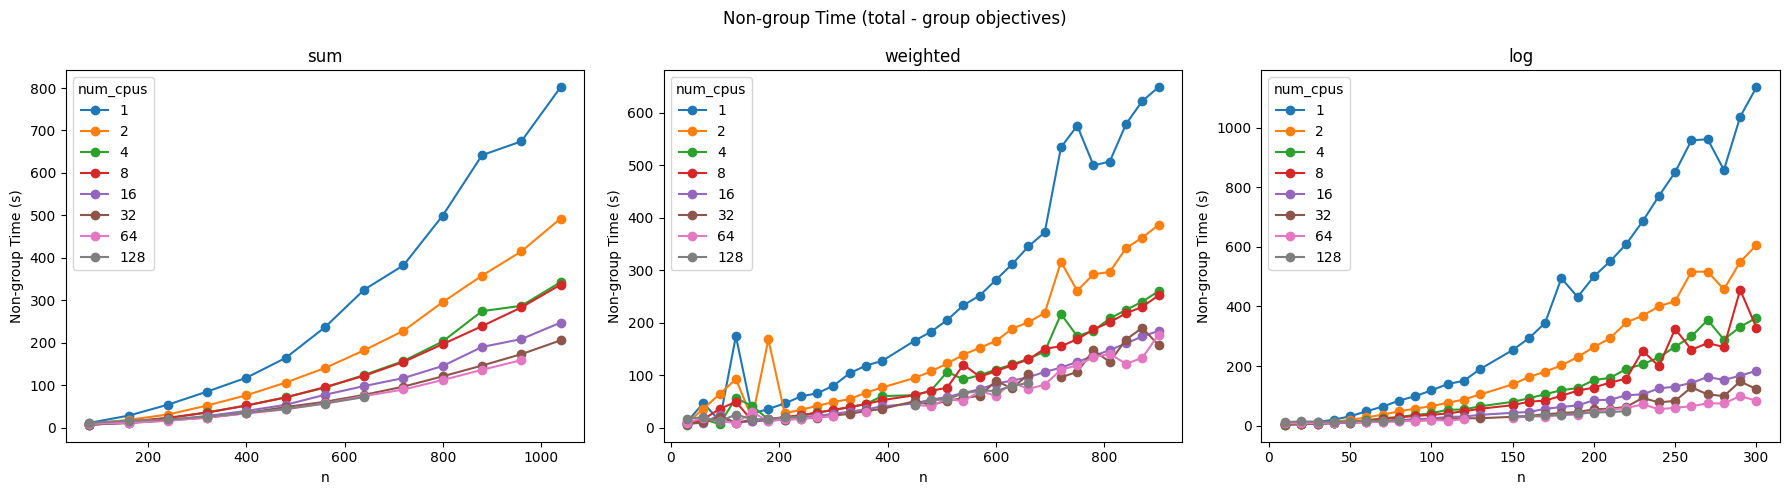

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    (df_t["total_time"] - df_t["group_time"]).plot(ax=ax, marker="o")
    ax.legend(df_t["total_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Non-group Time (s)")
    ax.set_title(test_type)
fig.suptitle("Non-group Time (total - group objectives)")
fig.tight_layout()
plt.show()

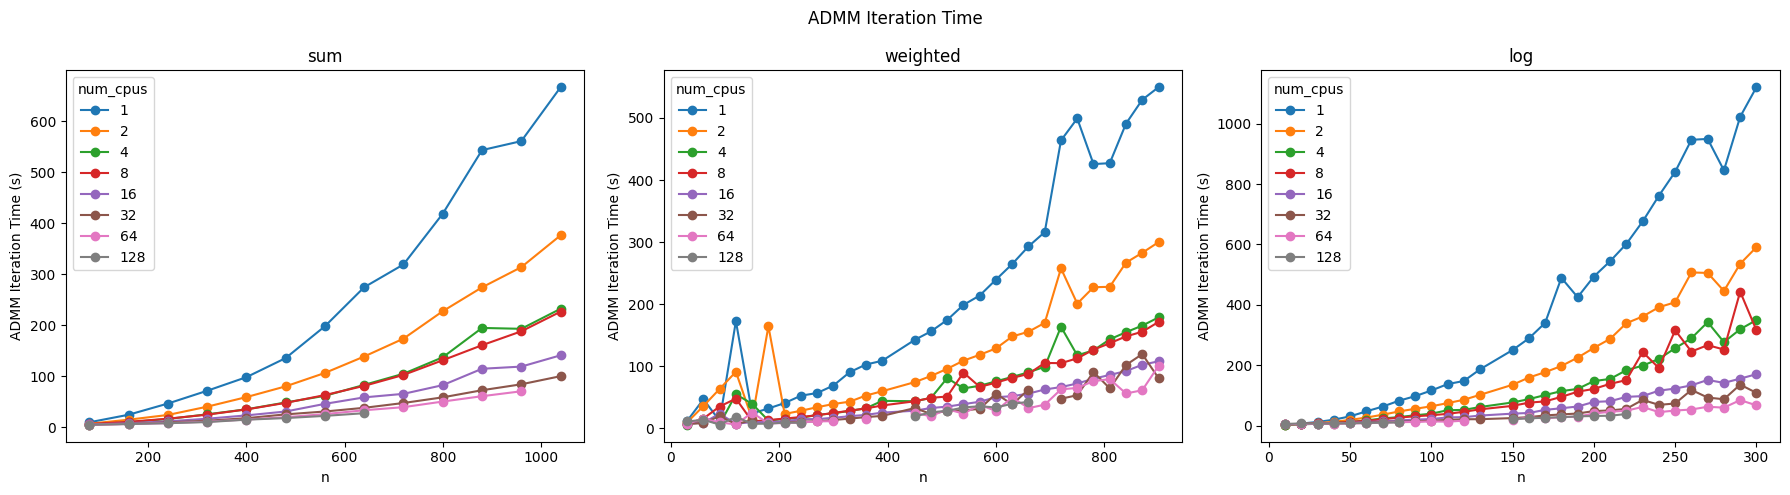

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["admm_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("ADMM Iteration Time (s)")
    ax.set_title(test_type)
fig.suptitle("ADMM Iteration Time")
fig.tight_layout()
plt.show()

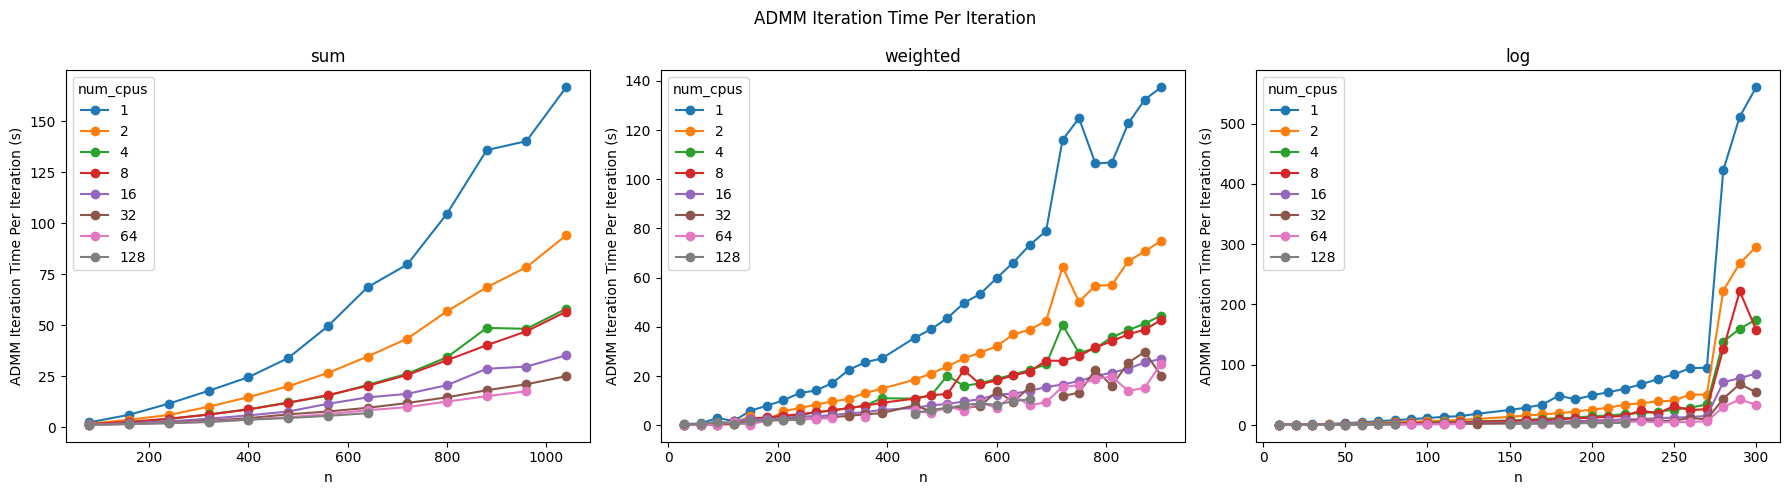

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["admm_time_per_iter"].plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time_per_iter"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("ADMM Iteration Time Per Iteration (s)")
    ax.set_title(test_type)
fig.suptitle("ADMM Iteration Time Per Iteration")
fig.tight_layout()
plt.show()

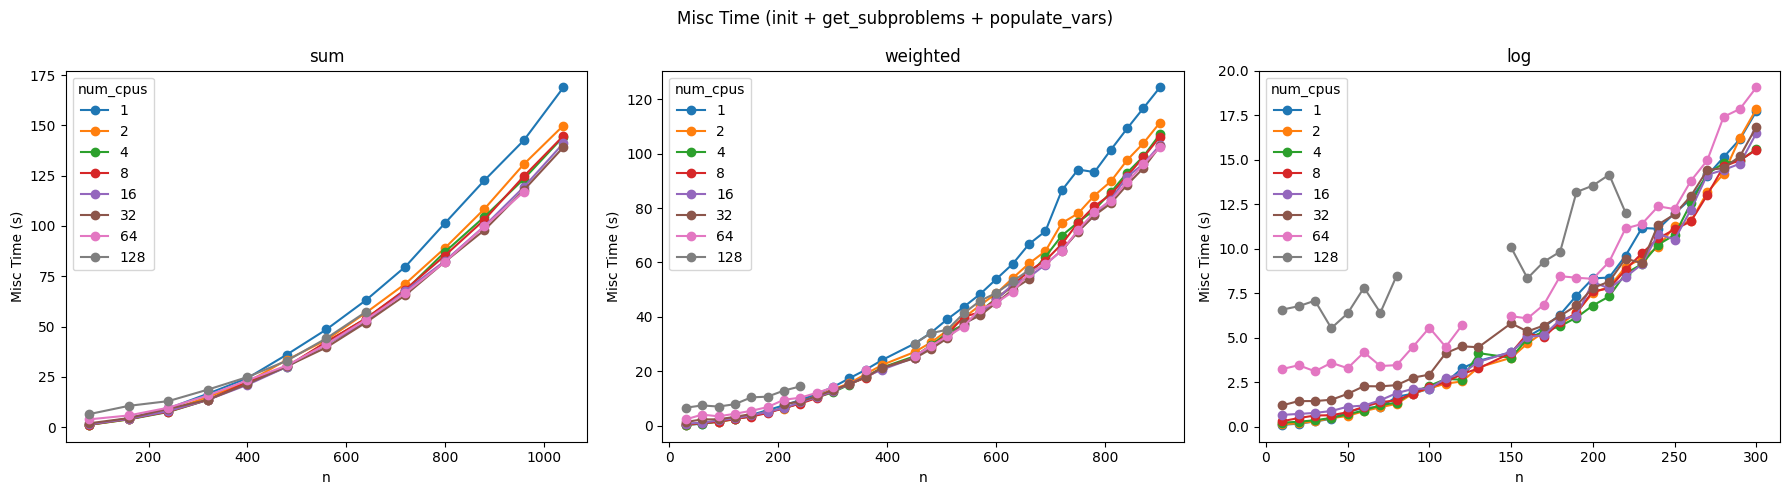

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["misc_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["misc_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Misc Time (s)")
    ax.set_title(test_type)
fig.suptitle("Misc Time (init + get_subproblems + populate_vars)")
fig.tight_layout()
plt.show()

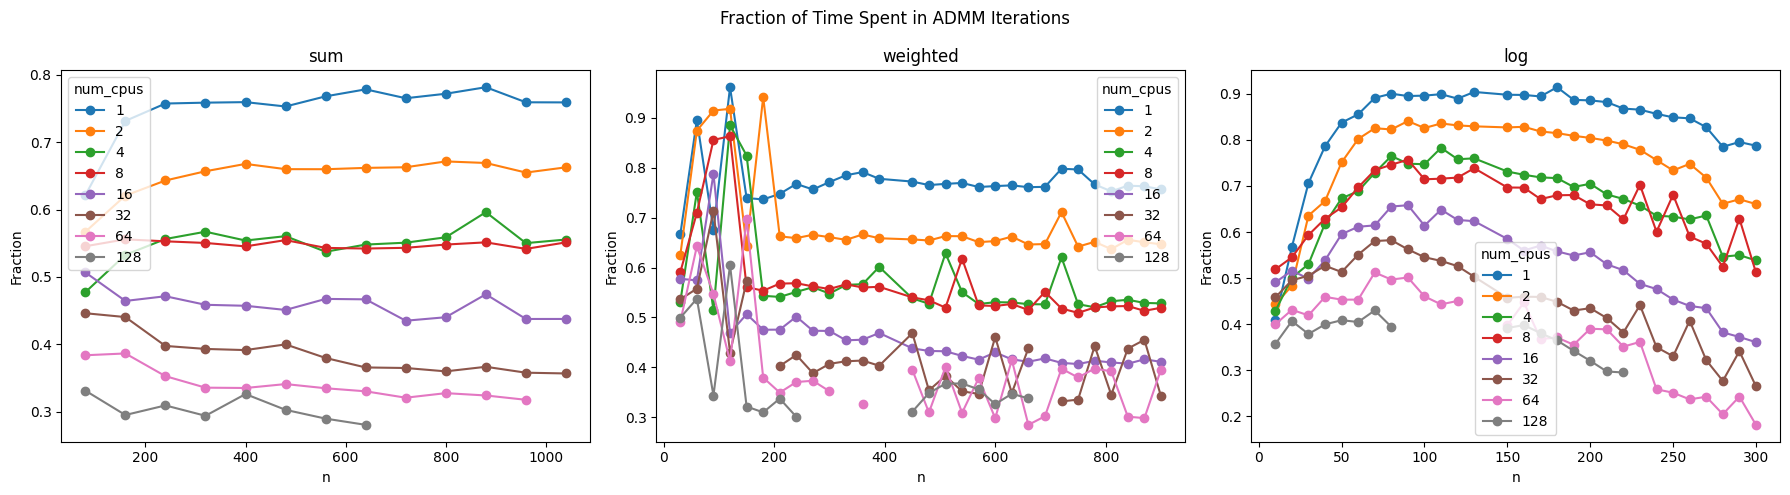

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    (df_t["admm_time"] / df_t["total_time"]).plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Fraction")
    ax.set_title(test_type)
fig.suptitle("Fraction of Time Spent in ADMM Iterations")
fig.tight_layout()
plt.show()

In [ ]:
dfs = []
for i in [1, 2, 4, 8, 16, 32, 64, 128]:
    dfs.append(pd.read_csv(f"{i}core.csv"))
df_cvxpy = pd.concat(dfs).set_index(["test_type", "n", "num_cpus"])
df_cvxpy

num_iterations        solve        result
test_type n    num_cpus                                           
sum       80   1                      0     0.191913  3.160000e+03
weighted  30   1                      0     0.043196  2.981250e+02
log       10   1                      0     0.031104  3.813026e+01
sum       160  1                      0     0.929441  1.272000e+04
weighted  60   1                      0     0.126334  4.216762e+02
...                                 ...          ...           ...
          870  128                    0   205.938760  4.852235e+03
log       290  128                    0    29.564076  3.002285e+03
sum       2400 128                    0  3491.920551  2.878800e+06
weighted  900  128                    0   215.513509  5.058256e+03
log       300  128                    0    30.414212  3.126041e+03

[720 rows x 3 columns]

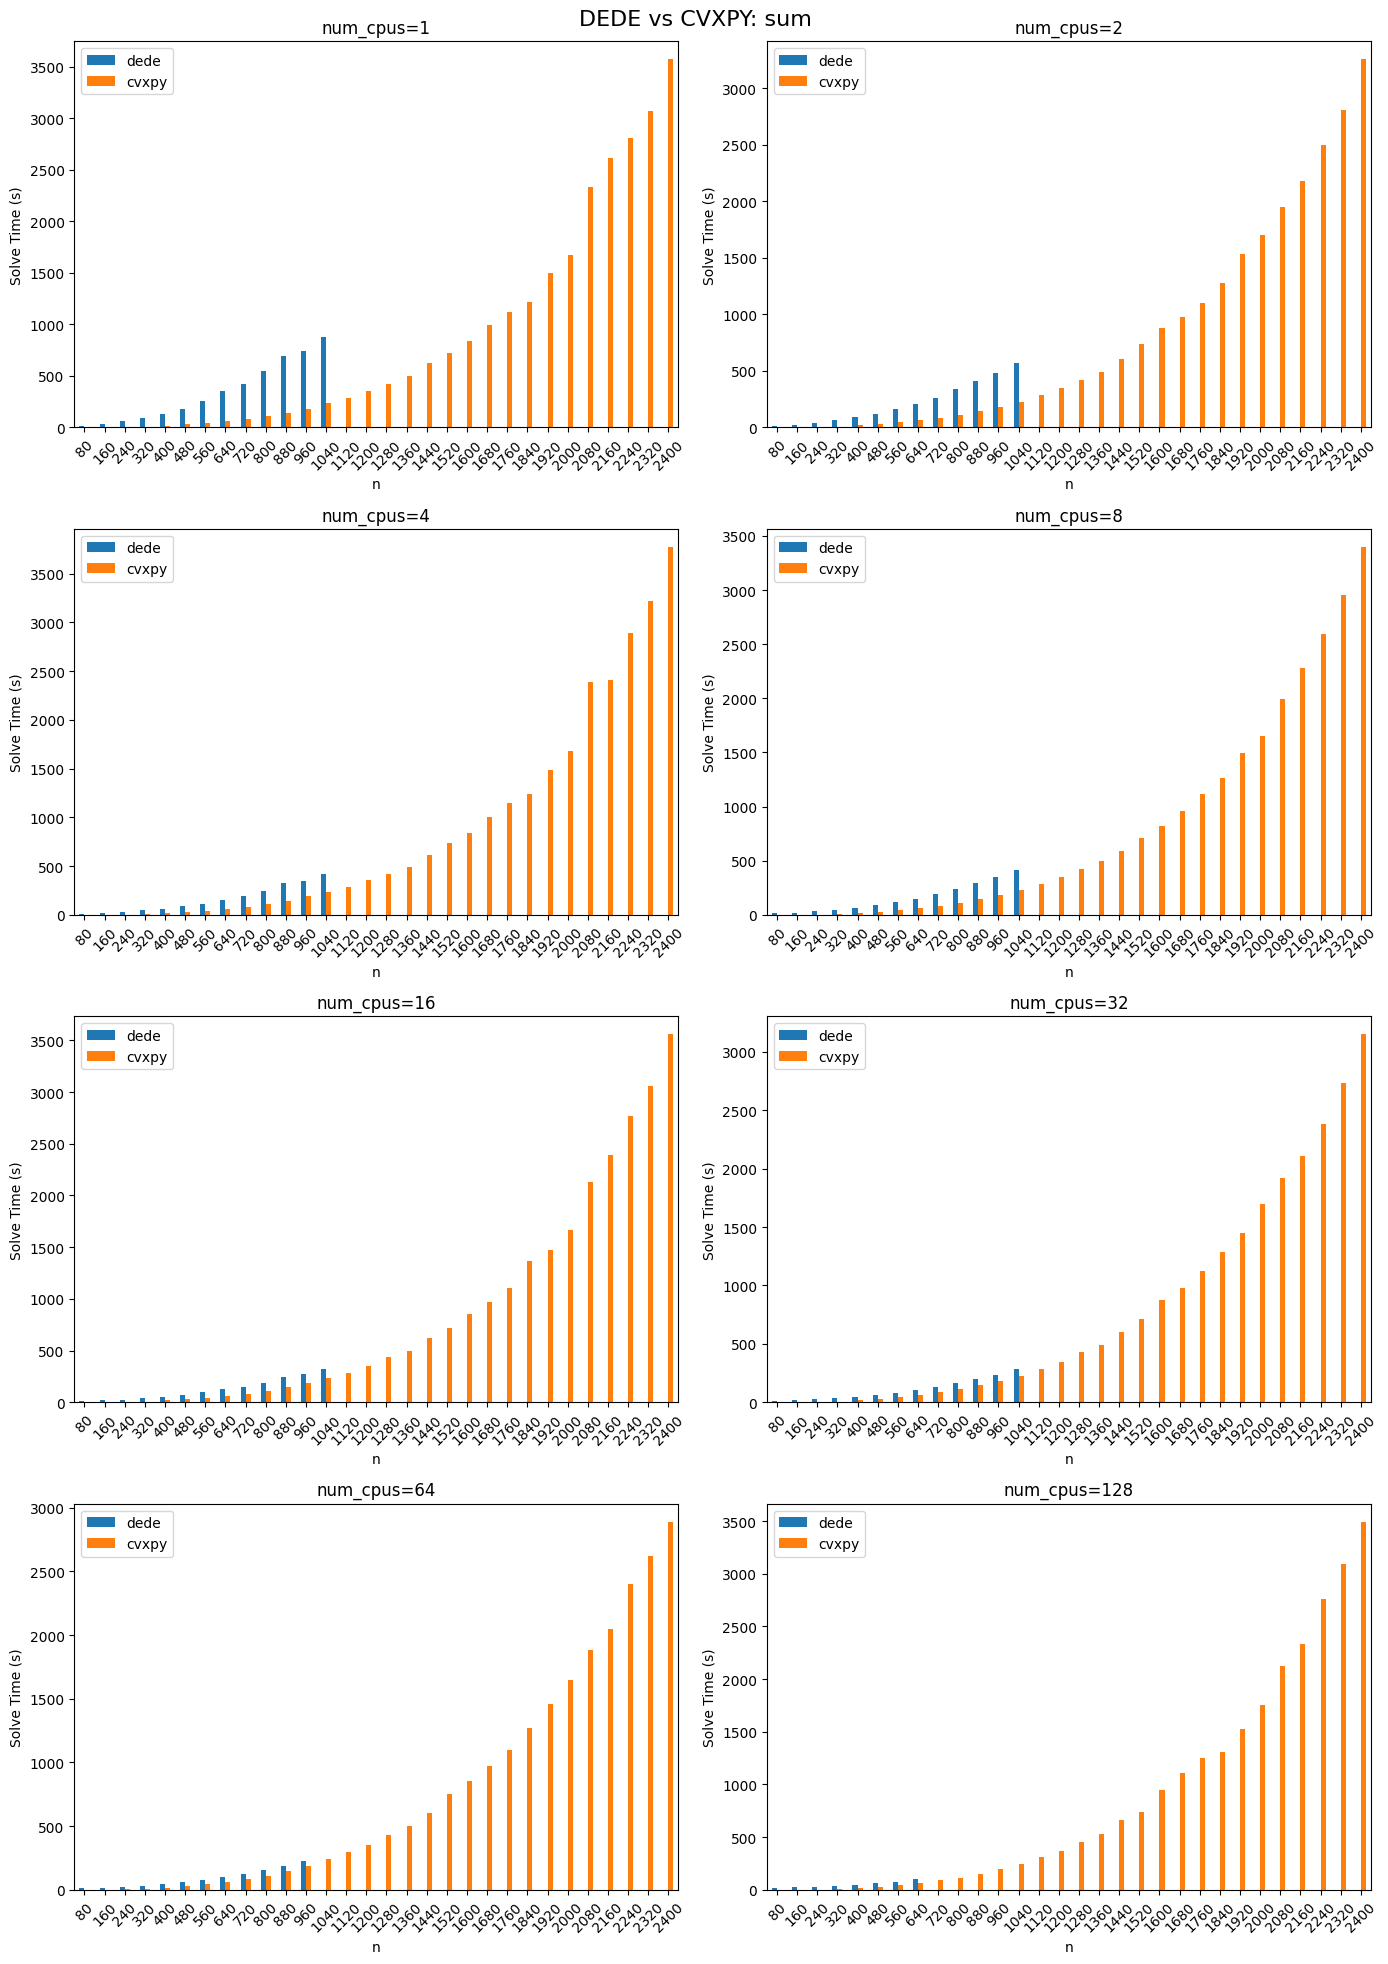

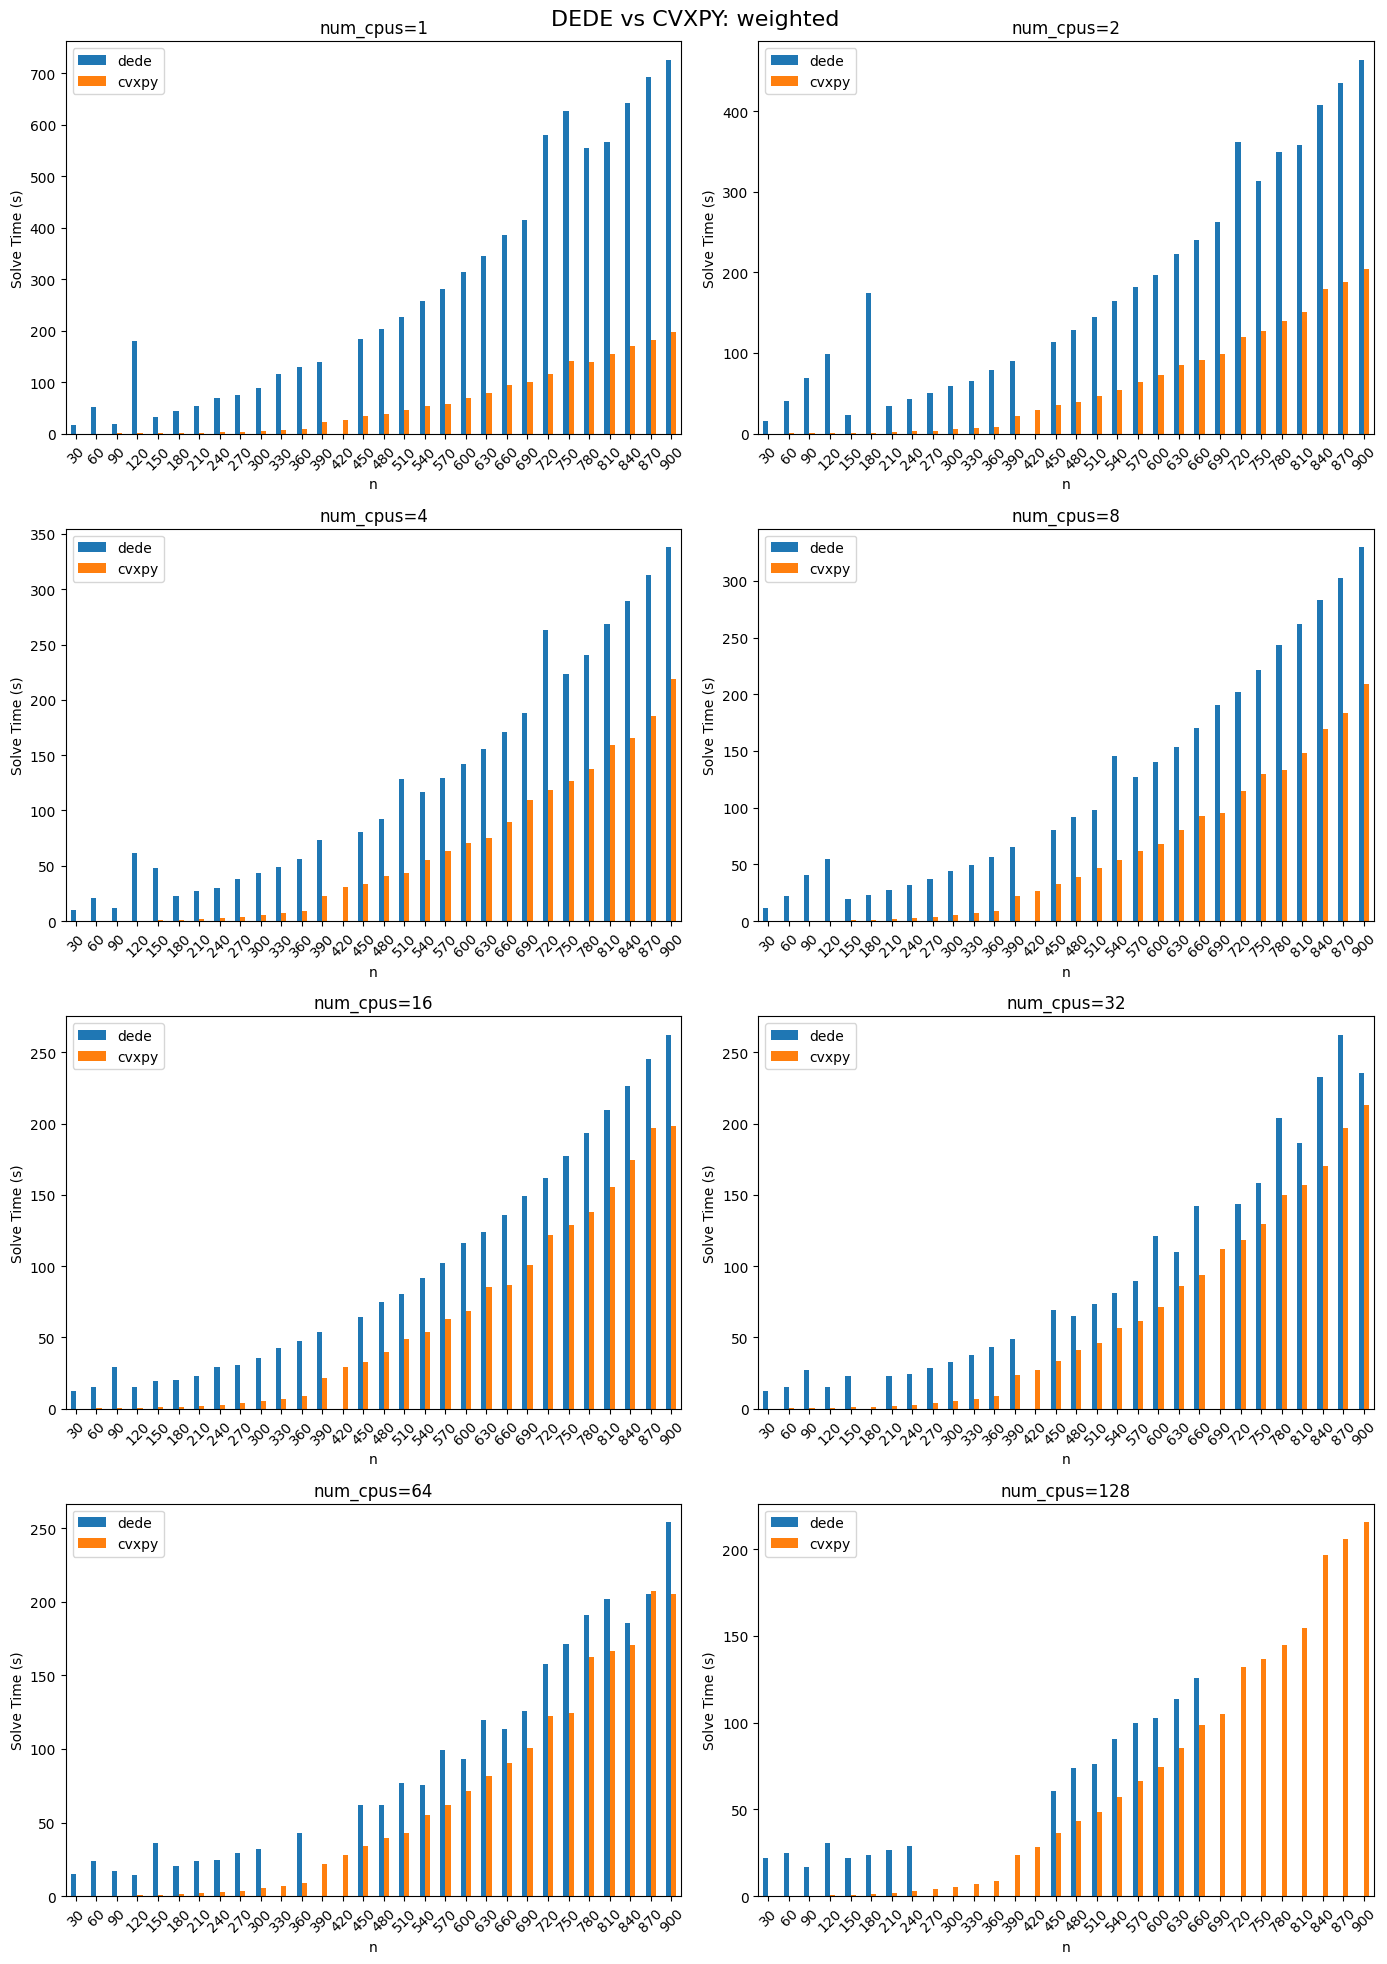

In [13]:
all_cpus = sorted(
    set(df.index.get_level_values("num_cpus")) | set(df_cvxpy.index.get_level_values("num_cpus"))
)

for test_type in TEST_TYPES:
    # TODO: fix this
    if test_type == "log":
        continue
    fig, axes = plt.subplots(4, 2, figsize=(14, 20))
    axes_flat = axes.flatten()

    for ax, num_cpus in zip(axes_flat, all_cpus):
        try:
            dede_s = df.loc[(test_type, slice(None), num_cpus), "total_time"]
            dede_s.index = dede_s.index.get_level_values("n")
        except KeyError:
            dede_s = pd.Series(dtype=float)
        try:
            cvxpy_s = df_cvxpy.loc[(test_type, slice(None), num_cpus), "solve"]
            cvxpy_s.index = cvxpy_s.index.get_level_values("n")
        except KeyError:
            cvxpy_s = pd.Series(dtype=float)

        combined = pd.DataFrame({"dede": dede_s, "cvxpy": cvxpy_s})
        combined.index.name = "n"
        combined.plot(kind="bar", ax=ax, rot=45)
        ax.set_title(f"num_cpus={num_cpus}")
        ax.set_xlabel("n")
        ax.set_ylabel("Solve Time (s)")

    for ax in axes_flat[len(all_cpus):]:
        ax.set_visible(False)

    fig.suptitle(f"DEDE vs CVXPY: {test_type}", fontsize=16)
    fig.tight_layout()
    plt.show()

In [29]:
merged = df_cvxpy.merge(df, how="left", on=["test_type", "n", "num_cpus"], suffixes=("_cvxpy", "_dede"))


In [38]:
diffs = merged[["result_cvxpy", "result_dede"]].loc[["sum", "weighted"]].astype(np.float64).dropna()
diffs["error"] = np.abs(diffs["result_cvxpy"] - diffs["result_dede"]) / np.abs(diffs["result_cvxpy"])

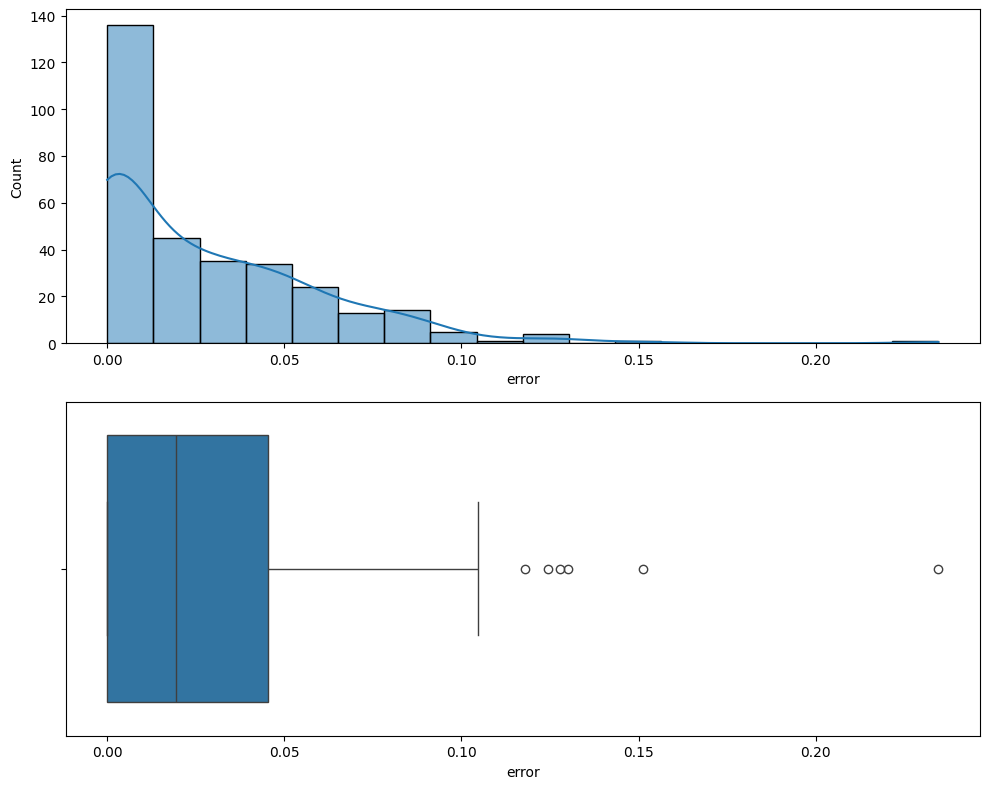

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
sns.histplot(diffs["error"], kde=True, ax=axes[0])
sns.boxplot(x=diffs["error"], ax=axes[1])
plt.tight_layout()
plt.show()